# Titanic Survival Analysis: A Data Visualization Case Study

**Name:** Pradip Chand <br>
BCT 5<sup>th</sup> Sem<br>
**CRN:** 26<br>

---

## Introduction

This case study analyzes the Titanic passenger dataset to explore
factors that influenced survival. The dataset contains information
about passengers including age, gender, ticket class, fare, and
survival status.

The objective of this analysis is to identify patterns and
relationships between passenger characteristics and survival
rates using data visualization techniques.

**source:** https://github.com/datasciencedojo/datasets/blob/master/titanic.csv

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("titanic.csv")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

### Data Cleaning

The dataset contained missing values in several columns such as Age,
Embarked, and Cabin. Missing values in the Age column were replaced
with the median age to maintain a realistic distribution.

The Embarked column had a few missing entries which were filled
using the most common port value. The Cabin column contained a
large number of missing values and was removed from the dataset.

Finally, the dataset was checked for duplicate records to ensure
data consistency before performing visualization.

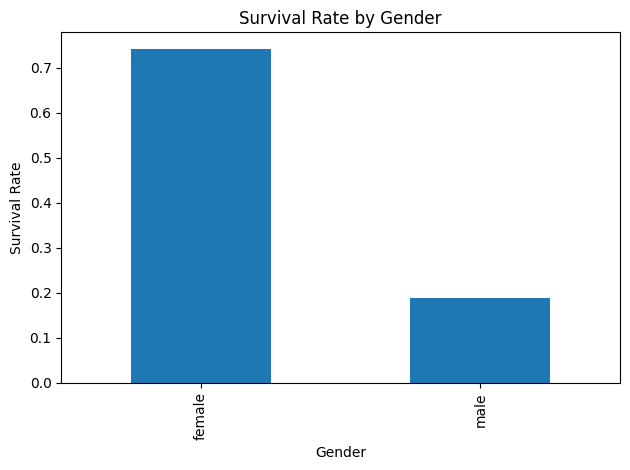

In [5]:
import matplotlib.pyplot as plt

df.groupby('Sex')['Survived'].mean().plot(kind='bar')

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig("bar_chart.png", dpi=150)

plt.show()



### Observation
Female passengers had a much higher survival rate than males.
Women were prioritized during evacuation according to
the "women and children first" policy.

### Implication:
Gender strongly influenced survival chances.

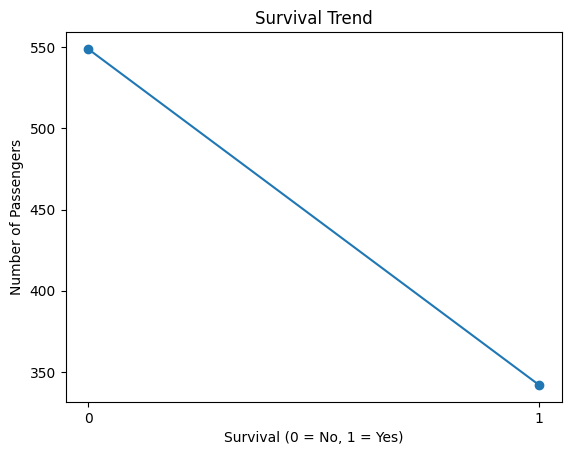

In [6]:
survival_counts = df['Survived'].value_counts().sort_index()

plt.figure()
plt.plot(survival_counts.index, survival_counts.values, marker='o')
plt.title("Survival Trend")
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.xticks([0,1])
plt.show()

### Observation 
This line graph shows the Survival Trend in Titanic here as we can see less people survived from the graph i.e more passenger are leaned toward 0 i.e death. 

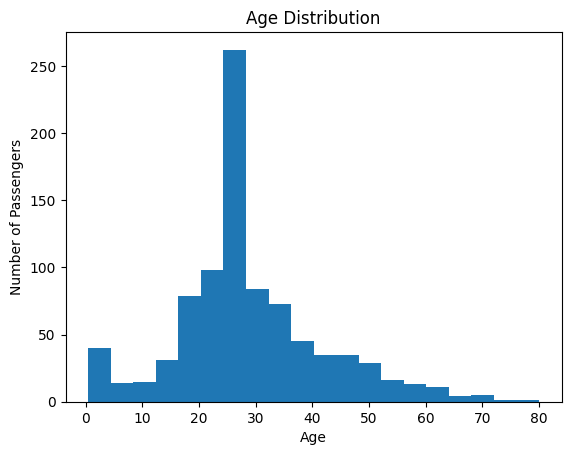

In [7]:
plt.figure()
plt.hist(df['Age'].dropna(), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

### Observation 
Here, we can see the age distribution between different age groups from the given histogram. Here, 250 people are between 20 and 30 age groups meaning there has been more amount of youth.

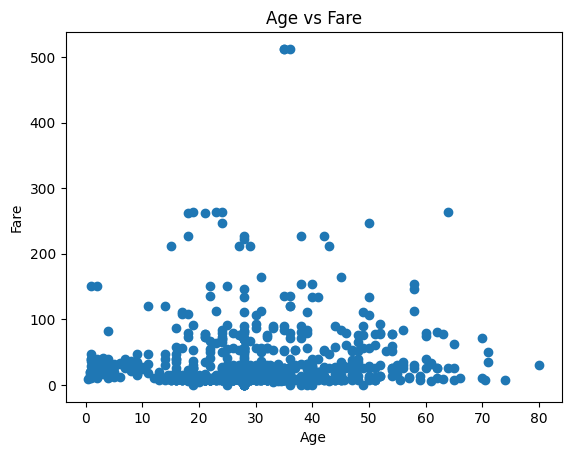

In [8]:
plt.figure()
plt.scatter(df['Age'], df['Fare'])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

### Observation 
Here, we can see the difference of age and fare i.e what age group what amount of fare making them certain class Passengers. Here age group between 30 and 40 have paid good fare we can see they are richer than most.

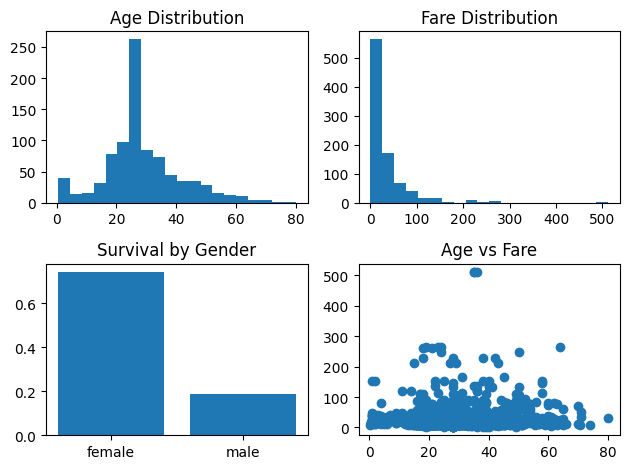

In [9]:
fig, axes = plt.subplots(2,2)

# Age Histogram
axes[0,0].hist(df['Age'].dropna(), bins=20)
axes[0,0].set_title("Age Distribution")

# Fare Histogram
axes[0,1].hist(df['Fare'], bins=20)
axes[0,1].set_title("Fare Distribution")

# Survival by Gender
survival_gender = df.groupby('Sex')['Survived'].mean()
axes[1,0].bar(survival_gender.index, survival_gender.values)
axes[1,0].set_title("Survival by Gender")

# Age vs Fare
axes[1,1].scatter(df['Age'], df['Fare'])
axes[1,1].set_title("Age vs Fare")

plt.tight_layout()
plt.show()

### Observation 
Here we can see all the previously mentioned subplots and compare them side by side. 
Females were safer than males. age group between 30 and 40 were richer, and youth were in majority in the ship.

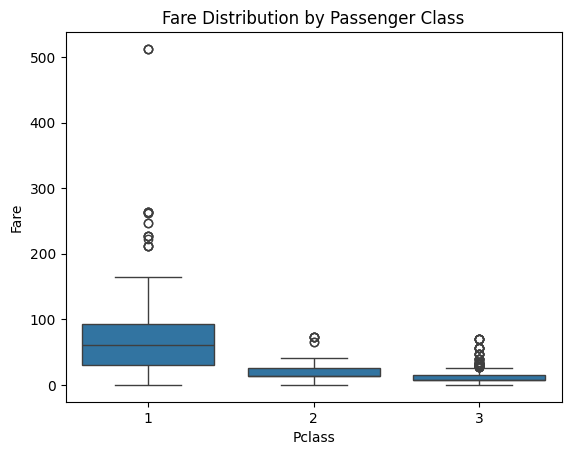

In [10]:
import seaborn as sns

sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare Distribution by Passenger Class")
plt.show()


### Observation 
Here from the first plot we can see that 1st class passenger have higher fare and 3rd class passenger have lower fare
where the highest fare is 500 which means thier survivality rate is higher than the ones in class 3. 

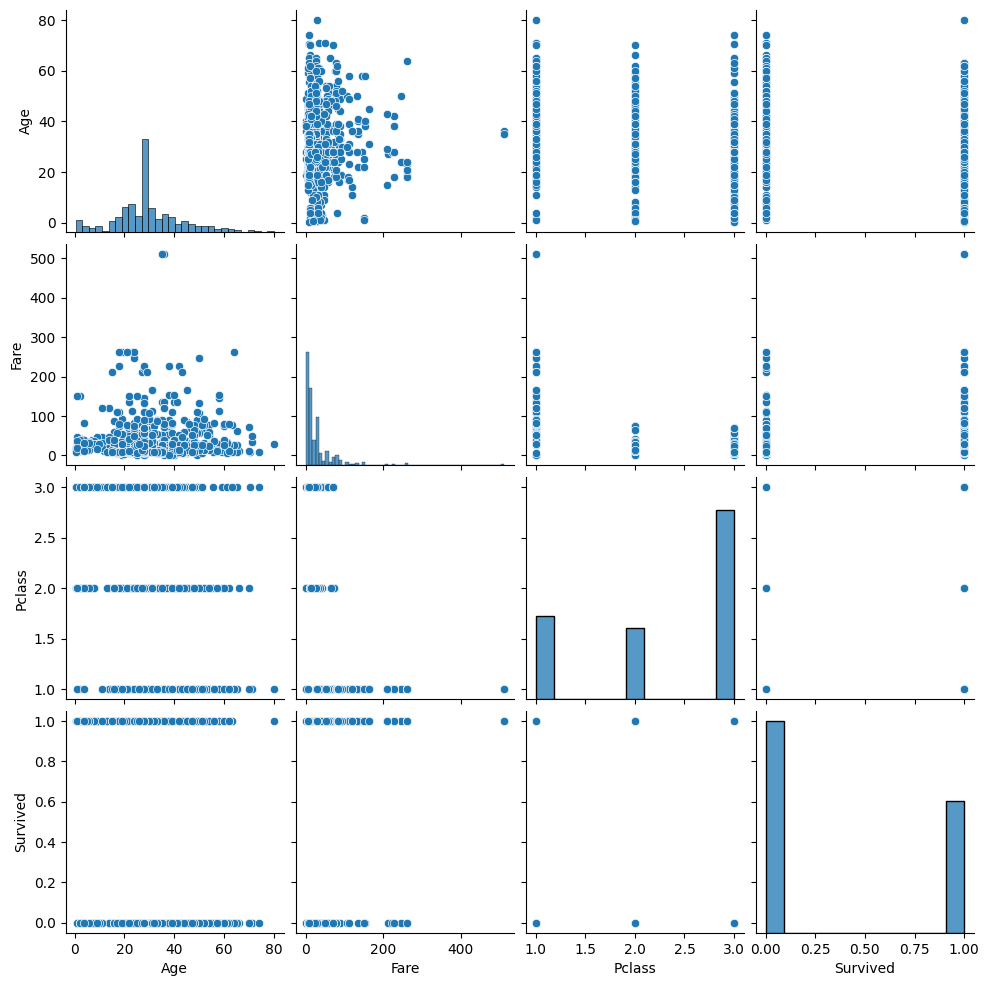

In [11]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']])

### Observation
From this paiplot, we can determine the majority in different groups i.e, youth were more in population i.e age group between 20 to 30 many people paid fare less than 100. More were inclined to class 3 treatment hence thier lower fare. Less survived in this tragic incident.

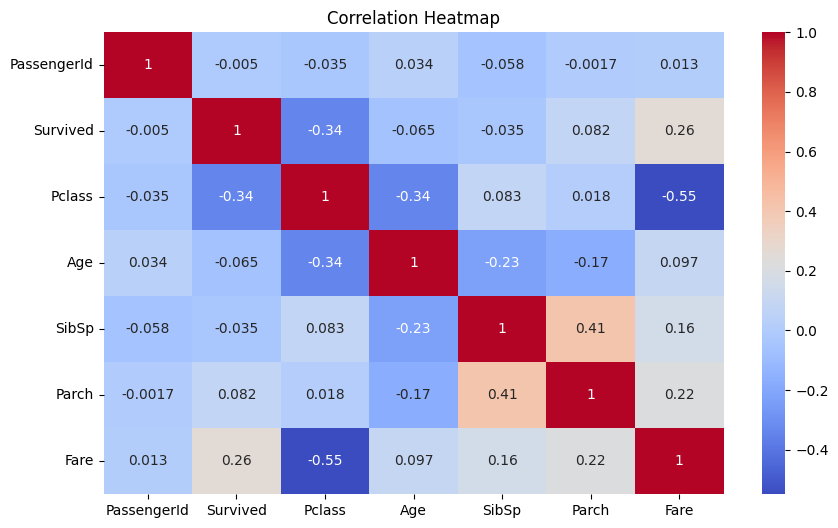

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Observation 
Here, we can see the Heatmap, we can see all the data compared together, i.e, all the data are compared with each other which giver us good estimation of what happened. for example, we can see better fare means better survivality, etc. 

In [13]:
import plotly.express as px

fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Survived",
    hover_data=["Sex","Pclass"]
)

fig.update_layout(title="Age vs Fare by Survival")
fig.show()














### Observation
Here we can see the difference between survival rate of either by fare or age group this is interactable plot since it is of plotly.

### Key Insights 

- Women had significantly higher survival rates than men.
- First-class passengers had a higher probability of survival.
- Younger passengers were more likely to survive compared
to older passengers.
- Higher ticket fares often corresponded with higher
survival rates due to class advantages.

## Conclusion
The most important finding is that passenger class and gender
strongly influenced survival outcomes.

However, this dataset has limitations such as missing values
and lack of detailed evacuation data.

Further analysis could include examining family relationships
or cabin locations to better understand survival patterns.